# 3. Slug Test - Falling Head

### Import packages

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import timflow.transient as tft

plt.rcParams["figure.figsize"] = [5, 3]

### Introduction and Conceptual Model

A well partially penetrates a sandy unconfined aquifer that has a saturated depth of 32.57 ft. The top of the screen is located 0.47 ft below the water table and has 13.8 ft in length. The well and casing radii are 5 and 2 inches, respectively. The slug displacement is 1.48 ft. Head change has been recorded at the slug well. This slug test, taken from the AQTESOLV examples (Duffield, 2007), was reported in Batu (1998). 

<img src="./figs/Falling_head.png" style="width:400pt">

### Load data

In [2]:
data = np.loadtxt("data/falling_head.txt", skiprows=2)
to = data[:, 0] / 60 / 60 / 24  # convert time from seconds to days
ho = (10 - data[:, 1]) * 0.3048  # convert drawdown from ft to meters

### Parameters and model

In [3]:
rw = 5 * 0.0254  # well radius, m
rc = 2 * 0.0254  # well casing radius, m
L = 13.8 * 0.3048  # screen length, m
b = 32.57 * 0.3048  # aquifer thickness, m
zt = 0  # top of aquifer, m
zst = -0.47 * 0.3048  # top of screen, m
zsb = zst - L  # bottom of screen, m
zb = zt - b  # bottom of aquifer, m
H0 = 1.48 * 0.3048  # initial displacement in well, m

convert measured displacement into volume

In [4]:
Q = np.pi * rc**2 * H0
print(f"slug: {Q:.5f} m^3")

slug: 0.00366 m^3


We will create a multi-layer model. For this, we divide the second and third layers into 0.5 m thick layers. 

In [5]:
# z = np.array([zt, zt - 0.1, zst, zsb, zb])
z = np.hstack(
    (
        zt,
        np.linspace(zt - 0.01, zst, 5)[:-1],
        np.linspace(zst, zsb, 5)[:-1],
        np.linspace(zsb, zb, 10),
    )
)
nlay = len(z) - 1

In [6]:
ml = tft.Model3D(
    kaq=10,
    z=z,
    Saq=[0.1] + (nlay - 1) * [1e-4],
    kzoverkh=1,
    tmin=1e-5,
    tmax=0.01,
    topboundary="phreatic",
)
w = tft.Well(
    ml,
    xw=0,
    yw=0,
    rw=rw,
    tsandQ=[(0, -Q)],
    layers=range(6, 6 + 5),
    rc=rc,
    wbstype="slug",
)
ml.solve()

self.neq  5
solution complete


### Estimate aquifer parameters

In [7]:
cal = tft.Calibrate(ml)
cal.set_parameter(name="kaq", layers=list(range(1, nlay)), initial=10, pmin=0)
cal.set_parameter(name="Saq", layers=list(range(1, nlay)), initial=1e-4, pmin=0)
cal.seriesinwell(name="obs", element=w, t=to, h=ho)
cal.fit(report=False)

...................................
Fit succeeded.


In [8]:
display(cal.parameters.loc[:, ["optimal"]])
print(f"RMSE: {cal.rmse():.3f} m")

,optimal
kaq_1_17,0.439175
Saq_1_17,0.000461


RMSE: 0.006 m


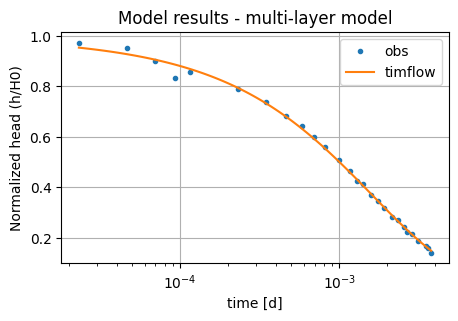

In [9]:
tm = np.logspace(np.log10(to[0]), np.log10(to[-1]), 100)
hm = w.headinside(tm)
plt.semilogx(to, ho / H0, ".", label="obs")
plt.semilogx(tm, hm[0] / H0, label="timflow")
plt.xlabel("time [d]")
plt.ylabel("Normalized head (h/H0)")
plt.title("Model results - multi-layer model")
plt.legend()
plt.grid()

### Comparison of results
Here, the `timflow` performance in analysing slug tests is checked. The solution in `timflow` is compared with the KGS analytical model (Hyder et al. 1994) implemented in AQTESOLV (Duffield, 2007). The parameters of `timflow` and AQTESOLV are similar, even though AQTESOLV only used one layer.

In [10]:
t = pd.DataFrame(
    columns=["k [m/d]", "Ss [1/m]", "RMSE [m]"],
    index=["timflow", "AQTESOLV"],
)

t.loc["timflow"] = np.append(cal.parameters["optimal"].values, cal.rmse())
t.loc["AQTESOLV"] = [0.4211, 5.70e-4, "-"]

t_formatted = t.style.format(
    {
        "k [m/d]": "{:.2f}",
        "Ss [1/m]": "{:.2e}",
        "RMSE [m]": lambda x: "-" if x == "-" else f"{float(x):.3f}",
    }
)
t_formatted

,k [m/d],Ss [1/m],RMSE [m]
timflow,0.44,4.61e-04,0.006
AQTESOLV,0.42,5.70e-04,-


## References

* Batu, V. (1998), Aquifer hydraulics: a comprehensive guide to hydrogeologic data analysis, John Wiley & Sons
* Duffield, G.M. (2007), AQTESOLV for Windows Version 4.5 User's Guide, HydroSOLVE, Inc., Reston, VA.
* Hyder, Z., Butler Jr, J.J., McElwee, C.D. and Liu, W. (1994), Slug tests in partially penetrating wells, Water Resources Research 30, 2945–2957.